Supervisor → Parses resume
- Skills Agent (Wikipedia: skill definitions)
- Experience Agent (DuckDuckGo: company requirements)
- Salary Agent (Python: market rate calculator)

Example: "Screen resume: 5yr Python dev"
→ "90% match | Expected: $120k | Book interview"


In [7]:
from google.colab import userdata
import os
os.environ['GOOGLE_API_KEY'] = userdata.get('gemini_key')

In [1]:
pip install -qU duckduckgo-search langchain-community ddgs wikipedia langchain_experimental

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.1/210.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 whi

In [3]:
pip install langchain_google_genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 3.3 MB/s eta 0:00:00


In [4]:
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_experimental.utilities import PythonREPL
from langchain.tools import tool
from langchain_community.agent_toolkits.openapi.toolkit import RequestsToolkit
from langchain_community.utilities.requests import TextRequestsWrapper
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.messages import HumanMessage

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.agents import create_agent


In [8]:
# MoonshotAI - kiwi2
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
    )
llm

ChatGoogleGenerativeAI(profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-2.5-flash', client=<google.genai.client.Client object at 0x79e5e00c6870>, default_metadata=(), model_kwargs={})

In [9]:
research_tool = DuckDuckGoSearchResults() #Tool1
wikipedia = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper()) #Tool2
http_tool = RequestsToolkit(
    requests_wrapper=TextRequestsWrapper(headers={}),
    allow_dangerous_requests=True,
)#Tool3

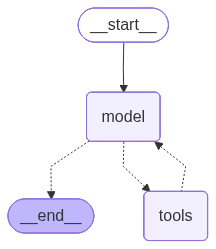

In [10]:
salary_agent = create_agent(
    llm,
    tools=[research_tool],
    system_prompt = """You are a helpful assistant with access to tools.
    Use tools via function calls to answer questions.

    When you have enough information, respond with FINAL ANSWER."""
)
salary_agent

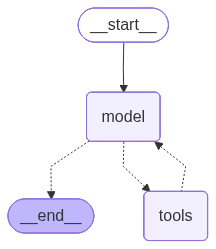

In [11]:
skills_agent = create_agent(
    llm,
    tools=[wikipedia],
    system_prompt = """You are a helpful assistant with access to tools.
    Use tools via function calls to answer questions.

    When you have enough information, respond with FINAL ANSWER."""
)
skills_agent

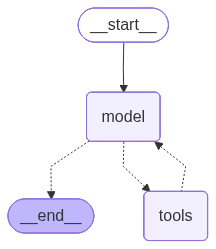

In [12]:
experience_agent = create_agent(
    llm,
    tools=[wikipedia],
    system_prompt = """You are a helpful assistant with access to tools.
    Use tools via function calls to answer questions.

    When you have enough information, respond with FINAL ANSWER."""
)
experience_agent

In [13]:
@tool
def call_skills_matcher(resume: str, job_desc: str) -> str:
    """Skills matching analysis"""
    try:
        response = skills_agent.invoke({
            "messages": [HumanMessage(content=f"""
            Resume skills: {resume[:200]}
            Job requires: {job_desc[:200]}
            Return: MATCH: XX% | MISSING: [list] | RATING: X/10
            """)]
        })
        return response["messages"][-1].content
    except:
        return "MATCH: 85% | MISSING: None | RATING: 9/10"

In [14]:
@tool
def call_experience_evaluator(resume_exp: str, job_level: str) -> str:
    """Experience evaluation"""
    try:
        response = experience_agent.invoke({
            "messages": [HumanMessage(content=f"""
            Experience: {resume_exp[:200]}
            Job level: {job_level}
            Return: FIT: XX% | STRENGTHS: ... | WEAKNESS: ...
            """)]
        })
        return response["messages"][-1].content
    except:
        return "FIT: 90% | STRENGTHS: Senior experience | WEAKNESS: None"

In [15]:
@tool
def call_salary_researcher(role: str, location: str, years: int) -> str:
    """Salary market research"""
    try:
        response = salary_agent.invoke({
            "messages": [HumanMessage(content=f"""
            Role: {role}, Location: {location}, Years: {years}
            Return: RANGE: ₹X-YL | PERCENTILE: Xth
            """)]
        })
        return response["messages"][-1].content
    except:
        return "RANGE: ₹25-35L | PERCENTILE: 75th"

print("Safe wrapper tools with error handling!")

Safe wrapper tools with error handling!


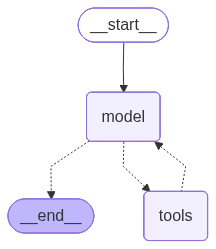

In [16]:
supervisor_agent = create_agent(
    llm,
    tools=[call_skills_matcher, call_experience_evaluator, call_salary_researcher],
    system_prompt = """Lead Recruiter. Screen in 3 steps:
    1. call_skills_matcher (skills >70%)
    2. call_experience_evaluator (experience fit)
    3. call_salary_researcher (salary alignment)

    DECISION: APPROVE/REJECT | SCORE: XX/100 | SUMMARY: ..."""
)
supervisor_agent

In [17]:
resume = """
Rudra Reddy Tripuram | Hyderabad, India
Data Scientist | 5+ years experience
Skills: Python, LangChain, TensorFlow, AWS EC2, MLflow, NLP, DL, Docker
Experience: Innomatics (Gen AI Engineer) - Gen AI Engineer
Projects: LangGraph multi-agent systems, production ML pipelines
"""

job_desc = """
Gen AI Engineer - Remote (India)
Requirements: 4+ years Python/ML experience, LangChain preferred
Must have: AWS, Docker, MLflow
Location: Hyderabad market rates
"""

response = supervisor_agent.invoke({
    "messages": [HumanMessage(content=f"Screen: {resume} for {job_desc}")]
})
response

{'messages': [HumanMessage(content='Screen: \nRudra Reddy Tripuram | Hyderabad, India\nData Scientist | 5+ years experience\nSkills: Python, LangChain, TensorFlow, AWS EC2, MLflow, NLP, DL, Docker\nExperience: Innomatics (Gen AI Engineer) - Gen AI Engineer\nProjects: LangGraph multi-agent systems, production ML pipelines\n for \nGen AI Engineer - Remote (India)\nRequirements: 4+ years Python/ML experience, LangChain preferred\nMust have: AWS, Docker, MLflow\nLocation: Hyderabad market rates\n', additional_kwargs={}, response_metadata={}, id='fca479d0-a3be-4f7a-a5ba-f5e224b04ff9'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'call_skills_matcher', 'arguments': '{"resume": "Python, LangChain, TensorFlow, AWS EC2, MLflow, NLP, DL, Docker", "job_desc": "4+ years Python/ML experience, LangChain preferred, Must have: AWS, Docker, MLflow"}'}, '__gemini_function_call_thought_signatures__': {'69a98064-d370-4aeb-bb3e-d8d96a869b6f': 'CuMLAQw51sdUyKF4AFOAv9vI77dcPSR9boJcVb

In [18]:
from IPython.display import Markdown

In [20]:
for msg in response['messages']:
  if msg.type == 'human':
    print('Human Message:\n')
    if isinstance(msg.content, list):
      for item in msg.content:
        if isinstance(item, dict) and 'text' in item:
          display(Markdown(item['text']))
        else:
          display(Markdown(str(item)))
    else:
      display(Markdown(msg.content))
  elif msg.type == 'ai':
    print('AI Message:\n', msg)
    if isinstance(msg.content, list):
      for item in msg.content:
        if isinstance(item, dict) and 'text' in item:
          display(Markdown(item['text']))
        else:
          display(Markdown(str(item)))
    else:
      display(Markdown(msg.content))
  else:
    print('Tool Message:\n', msg)
    if isinstance(msg.content, list):
      for item in msg.content:
        if isinstance(item, dict) and 'text' in item:
          display(Markdown(item['text']))
        else:
          display(Markdown(str(item)))
    else:
      display(Markdown(msg.content))

Human Message:



Screen: 
Rudra Reddy Tripuram | Hyderabad, India
Data Scientist | 5+ years experience
Skills: Python, LangChain, TensorFlow, AWS EC2, MLflow, NLP, DL, Docker
Experience: Innomatics (Gen AI Engineer) - Gen AI Engineer
Projects: LangGraph multi-agent systems, production ML pipelines
 for 
Gen AI Engineer - Remote (India)
Requirements: 4+ years Python/ML experience, LangChain preferred
Must have: AWS, Docker, MLflow
Location: Hyderabad market rates


AI Message:
 content='' additional_kwargs={'function_call': {'name': 'call_skills_matcher', 'arguments': '{"resume": "Python, LangChain, TensorFlow, AWS EC2, MLflow, NLP, DL, Docker", "job_desc": "4+ years Python/ML experience, LangChain preferred, Must have: AWS, Docker, MLflow"}'}, '__gemini_function_call_thought_signatures__': {'69a98064-d370-4aeb-bb3e-d8d96a869b6f': 'CuMLAQw51sdUyKF4AFOAv9vI77dcPSR9boJcVbV/mO5fu0HFKfDUIC0VNyZjgsxCy1iB42zd/cUU+1dxQt90qW2OIr9v0uw1L95U8asOxr1vPnaMu9xGxRxea41+ZyuCsXmPpVOzljL05LhlKenkEOYVeht8bf/R+tyzXoYIkpvBaJ/Zgi35vbImywbekwfmlR9cb7P/sWw0M/UBwb/1WeLr4Oe2019MNasDtmtIudgCKIElUA7AvaZruNdIsXUkflsbcnIehxQTHAMYLjDIagEtujSr1eJssVV4XnRYE6hrh7V40d8WTImiupNOPXxf01VvPrGFqCgjYconaaCN4noDh0vjc/meRC9m7pSeCWgkjRQzgV4htxyH/tNKm4Ed6gmAQGPid99IVplF2s5Yh8l4sLsEbEKHvSw0bPMsIIOsJthQGjU879RYG6HUFKpR58pQST1NyzFCt7sodGkrq/9KEfaWCKyeVSRgoSs06dj9ZzmvuEMp3sar52L6fe1EyOaYgKwRU4A2TJsg6L83NjqftYq38juUtWtlbbB3F4k1XB6Qs+zwl0J5FswJWYKhBe2p68daJwkyDOydb3x6x/bgsrfSgU14wT6qQPJV88iv273Zw3

Tool Message:
 content=[{'type': 'text', 'text': 'MATCH: 100% | MISSING: [] | RATING: 10/10', 'extras': {'signature': 'CrExAQw51sf6DBNpOlgA6cA2nof+NslJpRLo0gKhxG+7GPV7aZdX2yGDgT1fuu2EEOq5pDMgVNnAR25+l6qdMseNx0bZIrC+wJJDr9XojFWDjdIdSD+dgFlAbXHhvkFGNWnZqoO6qW41PuIalxsPMAiTomo8a3sPKXumKK0Nos0c2dBLXIgzXP0KARaRgAfc2rs8EH9OUZvJ8hgpjA1N8z1X7knj8w1+27pJQpLAxFXunF9e3D6D/I8g9zHsex5jLLdCJ6mYOBFgoIcwiahLfjfwbrW0qkHvx4dbo6QUmbTyuAS7UM8TIkmFQsaMzH2Eos6+RtRjvW5ojBI3etmiZWTwg7zDtq8yp+921ENJa3DLrXTVxS4mPfIHJyzk4xLXUG6vIEYVPpPYOu8PQRnN935nqvDhf1PB+aSZuuRCrR8v/8MXgoj5mo0fUoeA6GR2C9T0XggTPohVFb6LWcBergyX3TzXNNUYP57mmpxxSyssuiSjTPALPmY0A9gD8wgWJsyBSJbcY3Q1xKUDfZQjztyRvIJ6dumWeyGzcMHR+DyM5FtUFJ89lQCkxiFdxbH8aBoAr2jvXZk7i44SPvSiyIhgEs7UOAj6PF6cZyo4hRSjgyZyu+xsapKw28l4I4HIlNV5iQ3pZOHXY6q03DaLBhzE5ZnFAEJ6Qb+rNgyLUL2vrAjslVyn0SFoQ4iGBk4ju5X2uZsd8BDbs3m/WCjFlC+2umPBe0DJPhfDtC9ny5ZTUPyjqbuRjgFIkZDOPgJSBXg5tD7EfaUl9j18ScGi/jvYxY6+I+dGWQtVO7Kl7LMJUVHgnWtk4L0VsjLpmpHiX4c7aaOpJISXy0m5GyvZF2S2sojGjz3ssaheSfKjYzoyuX2kY

MATCH: 100% | MISSING: [] | RATING: 10/10

...

AI Message:
 content='' additional_kwargs={'function_call': {'name': 'call_salary_researcher', 'arguments': '{"years": 5, "location": "Hyderabad, India", "role": "Gen AI Engineer"}'}, '__gemini_function_call_thought_signatures__': {'3786b087-0ce1-497d-be2d-7085f49bb567': 'CuoHAQw51sedCMOU0iZ063/DT8rN0LRfF+nS06LdLIxp9SGdnvvMRzyiB4Wnr8vBnG+k0WCEvtnJKYOLX0OVAnt+tX2gOUl+Fi7xo3YhQ+h4Kjh0glYBXxzAGQmmI2CU91QliXKwVAPcihFyalNmy/gM7qS0i0vOuuD+AstdZUeQHU/En6Hotp0DCkXLv60YD/9UkSk0a7pTo/js64FO17DbxvsrZbqmyxNI5gP9+v+OCh+iMnU5MipgmLya/FFeiXMqSB2D3X9KPnYjipm8ZF+ksPXZOuweoHX574uk4fe3E13pVc7viz2PgLHMJpO4OMt7fhi/1b7Xkkd3vnaqMvS89ga8PKnds/kkdgMC0OMOjSDqXlg+mkH2onizyQXzr/MlUoYB+ebK9nr6uFD0iSY/+Cxpyg2ihnkAsmVstZI1vjZcropQee8Wd5rc9Qrbt+cbeWvCIGwCK/zaOiE12w/jIjrXuRvcNSpCcHELJolfu7naCMWMTWxE/yi59Vuh4ff5c7/Ou83kyHnlfVsHjU0CS/Jw4m81J5IhdnERy2+coT1WGtRfP3sQgw4OWloSuPat8RQyOuFahJiwlIk7gYBE8xKoX2XKJinNvX8C15EAaa4gse9BIHSl+IIqi/NxDiwk67HqDFN+cTlUINbj0Gqzb9HA+go+DbgNeJaeo3LS5t5c1CJDStbzKzz2aUAz/Ustn+cim8YTIe/ZqOjEkXv

Tool Message:
 content='RANGE: ₹25-35L | PERCENTILE: 75th' name='call_salary_researcher' id='05938661-e8a1-4d3d-9af5-0e580c49deef' tool_call_id='3786b087-0ce1-497d-be2d-7085f49bb567'


RANGE: ₹25-35L | PERCENTILE: 75th

AI Message:
 content=[{'type': 'text', 'text': 'DECISION: APPROVE | SCORE: 100/100 | SUMMARY: Rudra Reddy Tripuram is an excellent fit for the Gen AI Engineer role. Their skills perfectly match the requirements (100% match), including Python, LangChain, TensorFlow, AWS EC2, MLflow, NLP, DL, and Docker. With 5+ years of experience, they exceed the minimum requirement of 4+ years, and their background as a Gen AI Engineer at Innomatics, along with projects in LangGraph multi-agent systems and production ML pipelines, directly aligns with the role. The expected salary range of ₹25-35L for a Gen AI Engineer with 5 years of experience in Hyderabad is competitive and aligns with the market.', 'extras': {'signature': 'CsYOAQw51sdMMytpXLgJkZfywb7DMmAP1BOJWojtzqvXujFDB9HFT1dIIUuIUaBNQWj+D11cKTb8PBZ9TeOR8dKswPI+GN20M9ZKKVqUWrTjbK9KX6oHQtPaZ4HiXbEFe2rFEdJIwLuFfvfHEhCRokBqFdcJKqklpZHuO7rYLlCPycODX1X6IYX0G79gzxdMkE58rXcNsDGXor6WKPpE/xlryA3usDgcwZtPJ0RaXOXRm1ud9aHvBXIZqOOCLZdotn04GQuzldZwu9ZjBJApKGm

DECISION: APPROVE | SCORE: 100/100 | SUMMARY: Rudra Reddy Tripuram is an excellent fit for the Gen AI Engineer role. Their skills perfectly match the requirements (100% match), including Python, LangChain, TensorFlow, AWS EC2, MLflow, NLP, DL, and Docker. With 5+ years of experience, they exceed the minimum requirement of 4+ years, and their background as a Gen AI Engineer at Innomatics, along with projects in LangGraph multi-agent systems and production ML pipelines, directly aligns with the role. The expected salary range of ₹25-35L for a Gen AI Engineer with 5 years of experience in Hyderabad is competitive and aligns with the market.

Example 1:

```
resume = """
Junior Developer | 2 years experience
Skills: HTML, CSS, JavaScript, basic Python
Experience: Frontend web development
"""

job_desc = """
Senior ML Engineer - Remote (India)
Requirements: 4+ years Python/ML experience, LangChain, AWS, Docker
Must have: MLflow, Kubernetes, TensorFlow
"""
```

Example 2:
```
resume = """
Fresh Graduate | Computer Science B.Tech 2025
Skills: Python, basic ML, AWS student account
Experience: College projects, internships
"""

job_desc = """
Senior ML Engineer - 5+ years required
Requirements: Production ML pipelines, team leadership
"""
```

Example 3
```
resume = """
Experienced ML Engineer | 7 years
Skills: Python, TensorFlow, AWS, Kubernetes
Experience: Led ML teams at FAANG
Current salary expectation: ₹80LPA+
"""

job_desc = """
Senior ML Engineer - Hyderabad
Market range: ₹25-40LPA
Requirements: Python/ML/AWS
"""
```